## Quest #3 - Travel Destination Personalization

### Project Description
PlaceUp is an international travel company seeking to personalize destination recommendations for new users. This project builds a machine learning model that predicts a user's next travel destination (country_destination) based on profile data: age, gender, signup method, device type, and affiliate channel. The data was cleaned and explored, split into train and test sets, and used to train and compare three models: Logistic Regression, Random Forest, and XGBoost, with SHAP used to explain the predictions.

### KPIs
- **Macro F1-Score** (primary): Treats all 7 destination classes equally. Penalizes snapping to one class.
- **Accuracy** (secondary): Reference against US-only naive baseline (~38%).
- **Diversity**: Model must predict multiple destination classes, not collapse to always predicting US.

### Model Results
| Model | Accuracy | Macro F1 |
|---|---|---|
| Logistic Regression (baseline) | 19.37% | 0.187 |
| Random Forest | 25.15% | 0.281 |
| XGBoost (best) | 26.42% | 0.283 |

### How does the model balance Accuracy vs. Business Needs?
Raw accuracy is a misleading metric here. A naive model that always predicts 'US' achieves ~38% accuracy, higher than all our models, yet it provides zero business value as a recommendation system. Every user would get the same recommendation.

My approach prioritizes **diversity and explainability** over raw accuracy:
- I use **class_weight='balanced'** and **sample weights** so the model actively predicts all 7 destinations, not just the majority class.
- I use **Macro F1** as the primary metric, which treats all countries equally and penalizes the model for ignoring minority destinations like DE or IT.
- I use **SHAP** to explain every prediction - a business manager can understand WHY the model recommended Spain to a specific user (e.g., because they are 24 years old using a Mac).

This tradeoff is intentional: a slightly less accurate model that recommends diverse, explainable destinations is far more valuable to PlaceUp than a high-accuracy model that always says 'US'.

### Reflection Questions

**Q1 - Insights from the data and hypotheses tested during training:**
During the initial EDA, I noticed that age has a wide distribution and contains outliers, which suggested it could be a meaningful but noisy feature. I also noticed that device type varies across users, which led me to hypothesize that Mac users might lean toward certain destinations due to demographic correlations. Both hypotheses were confirmed by SHAP - age and Mac Desktop were the two strongest predictors.

**Q2 - What else could be explored with more time:**
With more time I would experiment with feature engineering - for example creating age groups instead of using raw age, or combining device type with signup method. I would also try hyperparameter tuning on XGBoost to improve performance. In terms of additional data, session and clickstream data (which destinations users browsed before booking) would likely be the biggest improvement to the model.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = pd.read_csv("PlaceUp_travel_users_dataset.csv")

In [113]:
df.head()

,user_id,age,gender,signup_method,signup_flow,affiliate_channel,first_device_type,country_destination
0,USER_00000,39.0,MALE,basic,0,sem-brand,Windows Desktop,NDF
1,USER_00001,32.0,OTHER,basic,0,sem-brand,iPhone,NDF
2,USER_00002,41.0,MALE,basic,0,direct,Windows Desktop,NDF
3,USER_00003,50.0,FEMALE,basic,0,direct,Windows Desktop,other
4,USER_00004,NaN,FEMALE,basic,0,sem-brand,Windows Desktop,US


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10000 non-null  str    
 1   age                  9200 non-null   float64
 2   gender               10000 non-null  str    
 3   signup_method        10000 non-null  str    
 4   signup_flow          10000 non-null  int64  
 5   affiliate_channel    10000 non-null  str    
 6   first_device_type    10000 non-null  str    
 7   country_destination  10000 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 625.1 KB


In [115]:
df['age'].describe()

count    9200.000000
mean       54.662717
std       201.471237
min        -5.000000
25%        26.000000
50%        34.000000
75%        41.000000
max      2014.000000
Name: age, dtype: float64

In [116]:
df['country_destination'].value_counts()

country_destination
NDF      4824
US       1969
other     796
ES        677
GB        525
IT        507
FR        426
DE        276
Name: count, dtype: int64

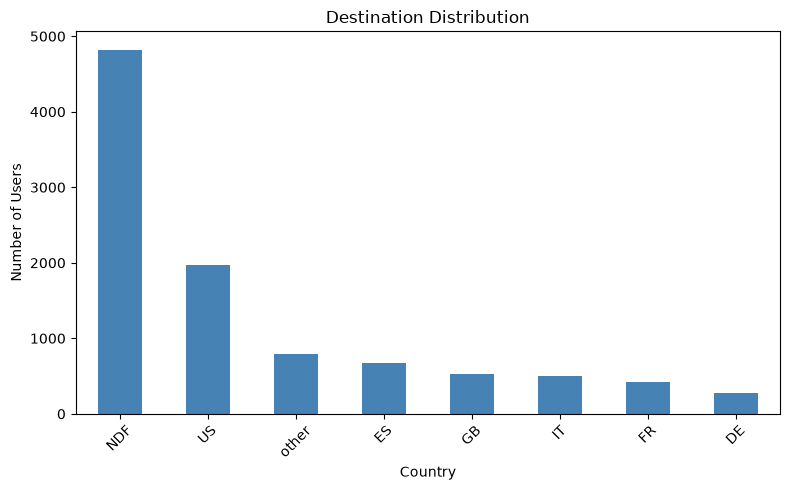

In [117]:
df['country_destination'].value_counts().plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.title('Destination Distribution')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [118]:
# Remove outliers (keep only valid ages or NaN)
df = df[(df['age'] >= 0) & (df['age'] <= 120) | (df['age'].isnull())]

# Remove NDF
df = df[df['country_destination'] != 'NDF']

In [119]:
from sklearn.model_selection import train_test_split

# Define features and target
y = df['country_destination']
X = df.drop(columns=['country_destination', 'user_id']) 

# Stratified 80/20 split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [120]:
# Fill remaining missing ages with median
median_age = X_train['age'].median()
X_train['age'] = X_train['age'].fillna(median_age)
X_test['age'] = X_test['age'].fillna(median_age)

In [121]:
# Encode categorical columns using one-hot encoding
X_train = pd.get_dummies(X_train, dtype=int)
X_test = pd.get_dummies(X_test, dtype=int)

# Align test set to have same columns as train set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [122]:
X_train.head()

,age,signup_flow,gender_FEMALE,gender_MALE,gender_OTHER,gender_UNKNOWN,signup_method_basic,signup_method_facebook,signup_method_google,affiliate_channel_direct,affiliate_channel_other,affiliate_channel_sem-brand,affiliate_channel_sem-non-brand,first_device_type_Android Phone,first_device_type_Mac Desktop,first_device_type_Windows Desktop,first_device_type_iPhone
9838,23.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1
8998,26.0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0
5089,26.0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0
2030,42.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1
4683,26.0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1


In [123]:
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
from sklearn.linear_model import LogisticRegression

# Train baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [125]:
from sklearn.metrics import accuracy_score

# Evaluate on test set
lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 19.37%


In [126]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Evaluate on test set
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 25.15%


In [127]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report

# XGBoost requires numeric labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# Train XGBoost with balanced weights
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)

xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_encoded, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")
print(classification_report(y_test_encoded, xgb_predictions, target_names=le.classes_))

XGBoost Accuracy: 26.42%
              precision    recall  f1-score   support

          DE       0.27      0.45      0.34        55
          ES       0.32      0.37      0.34       134
          FR       0.39      0.51      0.44        85
          GB       0.16      0.28      0.21       104
          IT       0.16      0.26      0.20        99
          US       0.41      0.14      0.21       388
       other       0.23      0.27      0.25       157

    accuracy                           0.26      1022
   macro avg       0.28      0.33      0.28      1022
weighted avg       0.31      0.26      0.26      1022



In [128]:
from sklearn.metrics import f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy],
    'Macro F1': [
        f1_score(y_test, lr_predictions, average='macro'),
        f1_score(y_test, rf_predictions, average='macro'),
        f1_score(y_test_encoded, xgb_predictions, average='macro')
    ]
})
results = results.sort_values('Macro F1', ascending=False)
print(results.to_string(index=False))

              Model  Accuracy  Macro F1
            XGBoost  0.264188  0.283185
      Random Forest  0.251468  0.265305
Logistic Regression  0.193738  0.187088


In [129]:
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

          DE       0.15      0.64      0.25        55
          ES       0.26      0.55      0.36       134
          FR       0.25      0.33      0.28        85
          GB       0.07      0.03      0.04       104
          IT       0.12      0.24      0.16        99
          US       0.27      0.01      0.02       388
       other       0.22      0.19      0.20       157

    accuracy                           0.19      1022
   macro avg       0.19      0.28      0.19      1022
weighted avg       0.22      0.19      0.14      1022



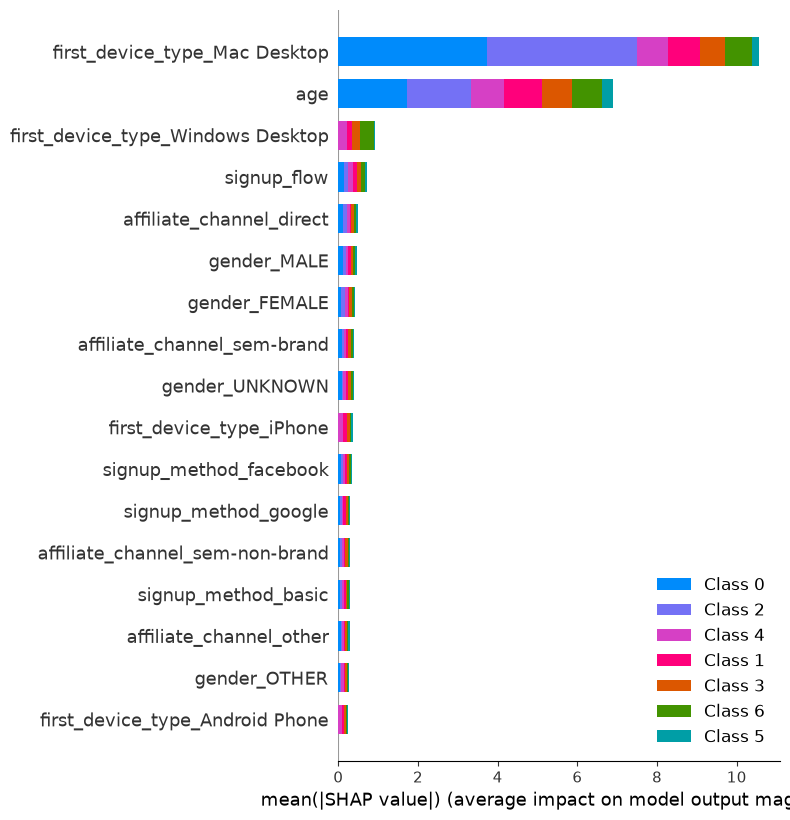

In [130]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

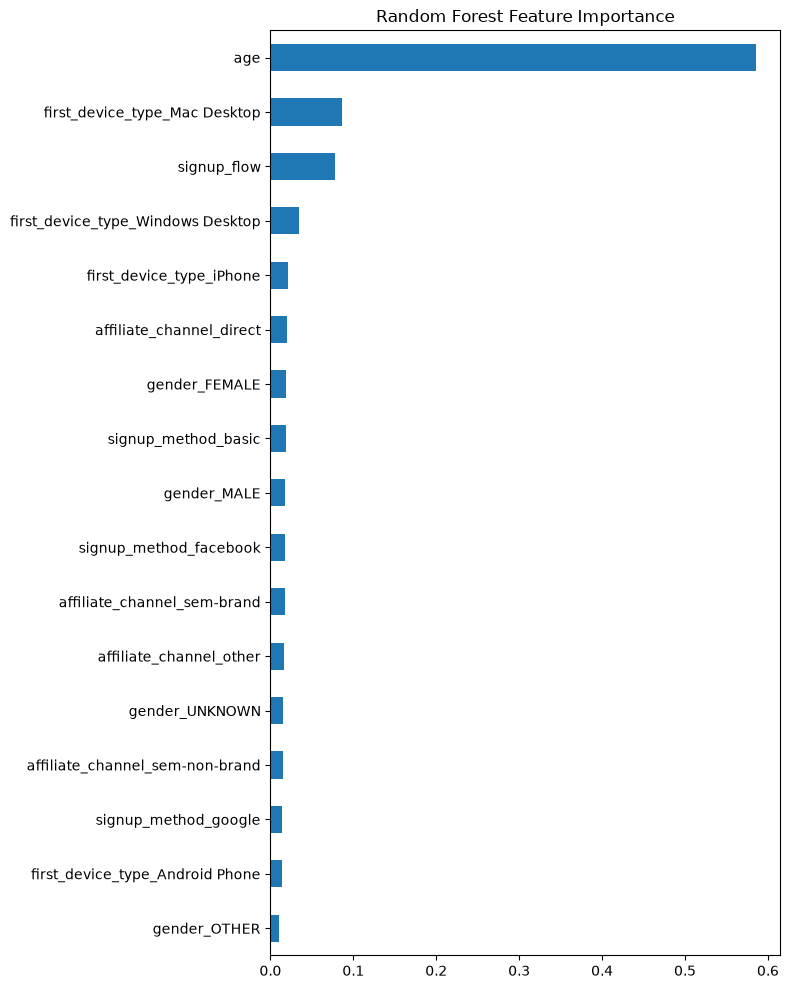

In [131]:
# Random Forest feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 10))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()